In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Benchmark shortlist (plan §5) — regression, not classification.
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Lasso, Ridge
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from catboost import CatBoostRegressor

# Pipelines. No SimpleImputer here: B_enriched has zero NaN by construction,
# which is precisely what the audit in the EDA notebook established.
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures, StandardScaler

# Splitting is grouped by country. A plain random CV would only re-measure the
# climate-fingerprint memorisation: (rain, temp) identifies the country exactly,
# so the same country on both sides of a split turns evaluation into a lookup.
from sklearn.model_selection import (
    GroupKFold,
    KFold,
    GroupShuffleSplit,
    RandomizedSearchCV,
    cross_validate,
)

# Metrics. `mean_squared_error(squared=False)` no longer exists in scikit-learn 1.9.
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.inspection import permutation_importance

import mlflow
import mlflow.sklearn
from mlflow import MlflowClient
from mlflow.models import infer_signature

RANDOM_STATE = 42

# Chart style, identical to the EDA notebooks
BLUE = "#2b7bba"
INK = "#333333"

# <a id='toc2_'></a>[Chargement des données](#toc0_)

## <a id='toc2_1_'></a>[Lecture du fichier CSV](#toc0_)

In [2]:
df = pd.read_csv("df.csv")
df


,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp,cropland_1000ha,pesticides_kg_per_ha,yield_t_per_ha
0,Albania,Maize,1990,36613,1485.0,121.00,16.37,704.00,0.171875,3.6613
1,Albania,Maize,1991,29068,1485.0,121.00,15.36,703.00,0.172119,2.9068
2,Albania,Maize,1992,24876,1485.0,121.00,16.06,703.00,0.172119,2.4876
3,Albania,Maize,1993,24185,1485.0,121.00,16.05,702.00,0.172365,2.4185
4,Albania,Maize,1994,25848,1485.0,201.00,16.96,702.00,0.286325,2.5848
...,...,...,...,...,...,...,...,...,...,...
14366,Zimbabwe,Wheat,2009,30000,657.0,3269.99,20.52,4138.32,0.790173,3.0000
14367,Zimbabwe,Wheat,2010,27681,657.0,3305.17,21.17,4036.77,0.818766,2.7681
14368,Zimbabwe,Wheat,2011,26274,657.0,3340.35,20.78,4237.18,0.788343,2.6274
14369,Zimbabwe,Wheat,2012,24420,657.0,3375.53,20.52,4090.14,0.825285,2.4420


# <a id='toc3_'></a>[Utilitaires](#toc0_)

## <a id='toc3_1_'></a>[Fonctions de logging MLflow](#toc0_)

In [3]:
def log_model(model, name, X_sample):
    """Log a fitted model, with the signature that makes it servable in step 3.

    cloudpickle, not the skops default: our inverse_func is a custom function, which
    skops refuses to reload ("UntrustedTypesFoundException"). cloudpickle also serializes
    functions BY VALUE -- including the LOG_MIN / LOG_MAX globals they reference -- so the
    artifact loads in the API process, which knows nothing of this notebook's __main__.
    """
    mlflow.sklearn.log_model(
        model,
        name=name,
        signature=infer_signature(X_sample, model.predict(X_sample)),
        input_example=X_sample.head(3),
        serialization_format="cloudpickle",
    )

## <a id='toc3_2_'></a>[Gestion des runs](#toc0_)

In [4]:
def delete_run_if_exists(experiment_name, run_name):
    client = MlflowClient()
    exp = client.get_experiment_by_name(experiment_name)
    if exp is None:
        return
    runs = client.search_runs(
        experiment_ids=[exp.experiment_id],
        filter_string=f"tags.mlflow.runName = '{run_name}'",
    )
    for run in runs:
        client.delete_run(run.info.run_id)

## <a id='toc3_3_'></a>[Pipeline sklearn](#toc0_)

In [5]:
CAT = ["Item"]
NUM = ["Year", "average_rain_fall_mm_per_year", "avg_temp", "pesticides_kg_per_ha"]


def encode(scale=False):
    """One-hot the crop, and scale the numerics too when the model is linear.

    HistGB needs neither: it reads the `category` dtype directly. RandomForest has no
    native categorical support, and CatBoost's own `cat_features` breaks sklearn's
    clone(), which cross_validate and the hyperparameter search both rely on.
    """
    onehot = ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CAT)
    if scale:
        # Modèles linéaires : chaque colonne est affectée, il ne reste rien.
        return ColumnTransformer([onehot, ("num", StandardScaler(), NUM)])
    # Arbres : le scaling ne sert à rien, mais il faut garder les numériques
    # explicitement — sinon ColumnTransformer les supprime.
    return ColumnTransformer([onehot], remainder="passthrough")


def _clipped_exp(z):
    """Back to t/ha, bounded by the yields actually observed during training.

    Reads LOG_MIN / LOG_MAX from the split cell: they must exist before any fit.
    Clipping happens in log space -- identical to clipping after exp(), since exp
    is monotone, but one step earlier.
    """
    return np.exp(np.clip(z, LOG_MIN, LOG_MAX))


def build(*steps):
    """Chain steps into a pipeline that trains on log(yield) and predicts back in t/ha.

    Crops span 1.26 to 16 t/ha: on the raw scale the loss is dominated by potatoes.
    """
    return TransformedTargetRegressor(
        regressor=make_pipeline(*steps), func=np.log, inverse_func=_clipped_exp
    )

# <a id='toc3_'></a>[Feature Engineering](#toc0_)

In [6]:
def clean_data(df):
    # cropland_1000ha only served to build pesticides_kg_per_ha, hg/ha_yield duplicates
    # the target in another unit, and pesticides_tonnes is a national total superseded
    # by the intensity (it mixes country size with farming practice).
    df = df.drop(columns=["cropland_1000ha", "hg/ha_yield", "pesticides_tonnes"])

    # HistGradientBoosting reads this dtype directly and needs no encoding on its side.
    df["Item"] = df["Item"].astype("category")

    return df


df_clean = clean_data(df.copy())
df_clean

,Area,Item,Year,average_rain_fall_mm_per_year,avg_temp,pesticides_kg_per_ha,yield_t_per_ha
0,Albania,Maize,1990,1485.0,16.37,0.171875,3.6613
1,Albania,Maize,1991,1485.0,15.36,0.172119,2.9068
2,Albania,Maize,1992,1485.0,16.06,0.172119,2.4876
3,Albania,Maize,1993,1485.0,16.05,0.172365,2.4185
4,Albania,Maize,1994,1485.0,16.96,0.286325,2.5848
...,...,...,...,...,...,...,...
14366,Zimbabwe,Wheat,2009,657.0,20.52,0.790173,3.0000
14367,Zimbabwe,Wheat,2010,657.0,21.17,0.818766,2.7681
14368,Zimbabwe,Wheat,2011,657.0,20.78,0.788343,2.6274
14369,Zimbabwe,Wheat,2012,657.0,20.52,0.825285,2.4420


# <a id='toc3_'></a>[Separation of sets](#toc0_)

In [7]:
X = df_clean[CAT + NUM]
y = df_clean["yield_t_per_ha"]



In [8]:
groups = df_clean["Area"]          # l'étiquette de groupe, PAS une feature de X

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
groups_train = groups.iloc[train_idx]

# Output bounds, derived from the TRAINING target only (using y would leak the test set).
# Predicting outside the range of yields ever observed is meaningless, and exp() turns a
# mild linear extrapolation into an absurd number: unbounded, Ridge reaches 27 000 t/ha
# on a country it has never seen.
LOG_MIN, LOG_MAX = np.log(y_train.min()), np.log(y_train.max())


In [15]:
# --- Contrôles du split ---
groups_test = groups.iloc[test_idx]

print(f"train : {len(X_train):>6,} lignes ({len(X_train)/len(X):.0%})   {groups_train.nunique():>3} pays")
print(f"test  : {len(X_test):>6,} lignes ({len(X_test)/len(X):.0%})   {groups_test.nunique():>3} pays")

# Invariant : aucun pays des deux côtés — c'est toute la raison d'être du split groupé
fuite = set(groups_train) & set(groups_test)
assert not fuite, f"fuite de pays : {sorted(fuite)}"
print("aucun pays commun aux deux jeux : OK")

# Les 10 cultures doivent rester évaluables des deux côtés
cultures = pd.DataFrame({
    "train": X_train["Item"].value_counts(),
    "test": X_test["Item"].value_counts(),
}).fillna(0).astype(int)
manquantes = list(cultures.index[cultures["test"] == 0])
print(f"cultures absentes du test : {manquantes or 'aucune'}")
display(cultures)

# Ordres de grandeur de la cible
print(f"cible train : médiane {y_train.median():.2f}   moyenne {y_train.mean():.2f}   max {y_train.max():.1f}")
print(f"cible test  : médiane {y_test.median():.2f}   moyenne {y_test.mean():.2f}   max {y_test.max():.1f}")


train : 11,550 lignes (80%)    87 pays
test  :  2,821 lignes (20%)    22 pays
aucun pays commun aux deux jeux : OK
cultures absentes du test : aucune


,train,test
Item,,
Cassava,895,138
Maize,1719,488
Plantains and others,464,46
Potatoes,1792,478
"Rice, paddy",1362,299
Sorghum,1227,321
Soybeans,1180,241
Sweet potatoes,1025,253
Wheat,1524,442


cible train : médiane 3.95   moyenne 7.08   max 49.6
cible test  : médiane 4.12   moyenne 6.94   max 50.1


# <a id='toc5_'></a>[Configuration MLflow](#toc0_)

In [9]:
EXPERIMENT_NAME = "crop_yield_B"

# A run left open by an interrupted cell would silently swallow the next one.
if mlflow.active_run():
    mlflow.end_run()

mlflow.set_tracking_uri("http://127.0.0.1:5000/")
mlflow.set_experiment(EXPERIMENT_NAME)

<Experiment: artifact_location='mlflow-artifacts:/1', creation_time=1786399633739, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1786399633739, lifecycle_stage='active', name='crop_yield_B', tags={}, trace_location=None, workspace='default'>

# <a id='toc5_'></a>[Modelisation](#toc0_)

## <a id='toc6_1_'></a>[Fonction run_cv](#toc0_)

In [14]:
SCORING = {
    "rmse": "neg_root_mean_squared_error",
    "mae": "neg_mean_absolute_error",
    "r2": "r2",
}


def run_cv(model, run_name, X, y, groups, cv=None, tags=None):
    """Cross-validate one model, log it to MLflow, print a one-line summary.

    `cv` carries the evaluation protocol: GroupKFold by country by default, but the
    same function serves the random and temporal protocols of the plan. The temporal
    one is a plain list of index pairs, so pass tags={"cv": "temporal"} for it --
    type(cv).__name__ would only say "list".
    """
    delete_run_if_exists(EXPERIMENT_NAME, run_name)
    cv = cv or GroupKFold(n_splits=5)
    tags = tags or {}
    estimator = model.regressor.steps[-1][1]   # the model at the end of the pipeline

    with mlflow.start_run(run_name=run_name, tags=tags):
        scores = cross_validate(model, X, y, groups=groups, cv=cv, scoring=SCORING)

        # Only the final estimator's params: get_params() on the whole wrapper returns
        # the nested pipeline, which flirts with MLflow's 100-param cap and makes the
        # comparison table unreadable. Values are capped at MLflow's 250-char limit.
        mlflow.log_params({k: str(v)[:250] for k, v in estimator.get_params().items()})

        # Which columns fed the model, and over how many folds it was scored. Without
        # these, runs from different feature sets or fold counts look identical.
        mlflow.log_param("features", ", ".join(X.columns)[:250])
        mlflow.log_param("n_features", X.shape[1])
        mlflow.log_param("cv_n_splits", len(scores["test_r2"]))

        mlflow.set_tag("model_family", type(estimator).__name__)
        if "cv" not in tags:                   # never clobber a caller-supplied label
            mlflow.set_tag("cv", type(cv).__name__)

        metrics = {}
        for key, scorer in SCORING.items():
            # the neg_* scorers return negatives; r2 keeps its sign (it can be < 0)
            values = scores[f"test_{key}"] * (-1 if scorer.startswith("neg_") else 1)
            metrics[f"{key}_mean"] = values.mean()
            metrics[f"{key}_std"] = values.std()
        mlflow.log_metrics(metrics)

        model.fit(X, y)
        log_model(model, run_name, X.head(5))

        r2, rmse = scores["test_r2"], -scores["test_rmse"]

        # Fold-by-fold R2: r2_std says how unstable the model is, this shows where.
        # Skipped on single-fold protocols (temporal), where one bar shows nothing.
        if len(r2) > 1:
            fig, ax = plt.subplots(figsize=(5, 2.5))
            ax.bar(range(1, len(r2) + 1), r2, color=BLUE, alpha=0.8)
            ax.axhline(r2.mean(), color=INK, ls="--", lw=1, label=f"moyenne {r2.mean():+.3f}")
            ax.set_xticks(range(1, len(r2) + 1))
            ax.set_xlabel("pli")
            ax.set_ylabel("R²")
            ax.set_title(run_name, fontsize=10)
            ax.legend(frameon=False, fontsize=8)
            sns.despine(fig=fig)
            fig.tight_layout()
            mlflow.log_figure(fig, "r2_par_pli.png")

        print(f"{run_name:<22} R2 = {r2.mean():+.3f} ± {r2.std():.3f}   "
              f"RMSE = {rmse.mean():.2f} t/ha")

## <a id='toc6_1_'></a>[Dummy](#toc0_)

c:\Users\Kevin\projects\OC_P12\.venv\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
2026/08/11 18:47:49 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary

Dummy — grouped        R2 = -0.164 ± 0.041   RMSE = 8.39 t/ha
🏃 View run Dummy — grouped at: http://127.0.0.1:5000/#/experiments/1/runs/59faab3d38e74a33bdc1349022fbf502
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


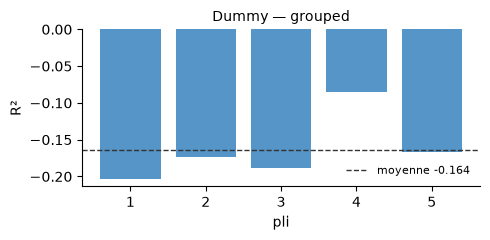

In [15]:
run_cv(build(DummyRegressor(strategy="median")), "Dummy — grouped", X_train, y_train, groups_train)

c:\Users\Kevin\projects\OC_P12\.venv\Lib\site-packages\sklearn\model_selection\_split.py:86: UserWarning: The groups parameter is ignored by KFold
  warnings.warn(
c:\Users\Kevin\projects\OC_P12\.venv\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
2026/08/11 18:47:55 WARNING mlflow.sklearn: Saving scikit-learn model

Dummy — random         R2 = -0.160 ± 0.007   RMSE = 8.42 t/ha
🏃 View run Dummy — random at: http://127.0.0.1:5000/#/experiments/1/runs/dd863d55452b43bcb439429d822cea5b
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


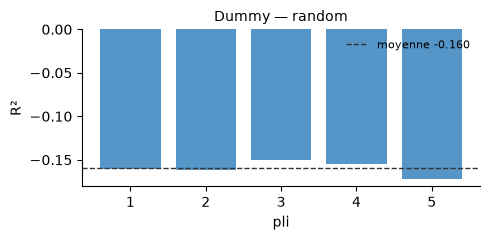

In [16]:
run_cv(build(DummyRegressor(strategy="median")), "Dummy — random", X_train, y_train, groups_train,cv=KFold(5, shuffle=True, random_state=RANDOM_STATE))


## <a id='toc6_1_'></a>[Ridge](#toc0_)

c:\Users\Kevin\projects\OC_P12\.venv\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
2026/08/11 18:47:58 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary

Ridge — grouped        R2 = +0.415 ± 0.266   RMSE = 5.86 t/ha
🏃 View run Ridge — grouped at: http://127.0.0.1:5000/#/experiments/1/runs/4e34de7a40224110a9d04ee2e7f801e1
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


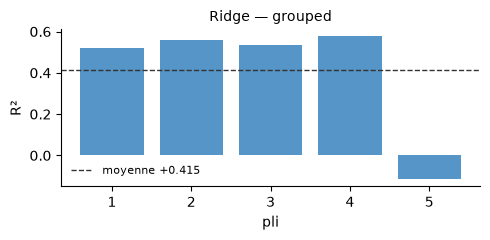

In [17]:
run_cv(build(encode(scale=True),
             PolynomialFeatures(2, interaction_only=True, include_bias=False),
             Ridge(alpha=1.0)),
       "Ridge — grouped", X_train, y_train, groups_train)


c:\Users\Kevin\projects\OC_P12\.venv\Lib\site-packages\sklearn\model_selection\_split.py:86: UserWarning: The groups parameter is ignored by KFold
  warnings.warn(
c:\Users\Kevin\projects\OC_P12\.venv\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
2026/08/11 18:48:02 WARNING mlflow.sklearn: Saving scikit-learn model

Ridge — random         R2 = +0.594 ± 0.010   RMSE = 4.98 t/ha
🏃 View run Ridge — random at: http://127.0.0.1:5000/#/experiments/1/runs/4e90adaaab024ee6bc91a29ec9dab19b
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


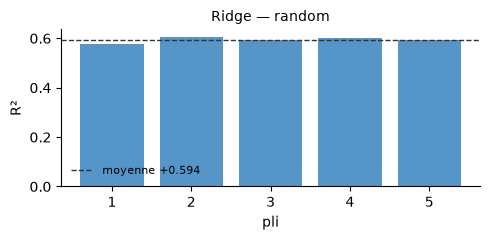

In [18]:
run_cv(build(encode(scale=True),
             PolynomialFeatures(2, interaction_only=True, include_bias=False),
             Ridge(alpha=1.0)),
       "Ridge — random", X_train, y_train, groups_train,cv=KFold(5, shuffle=True, random_state=RANDOM_STATE))

## <a id='toc6_1_'></a>[Lasso](#toc0_)

c:\Users\Kevin\projects\OC_P12\.venv\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
2026/08/11 18:48:05 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary

Lasso — grouped        R2 = +0.412 ± 0.251   RMSE = 5.87 t/ha
🏃 View run Lasso — grouped at: http://127.0.0.1:5000/#/experiments/1/runs/e4001d90aea1409880ffcef2463bf34b
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


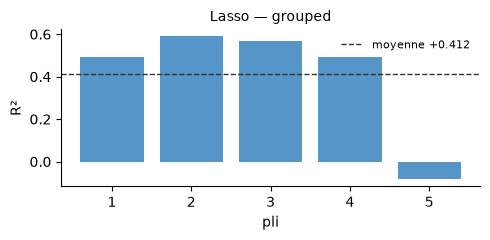

In [19]:
run_cv(build(encode(scale=True),
             PolynomialFeatures(2, interaction_only=True, include_bias=False),
             Lasso(alpha=0.01)),
       "Lasso — grouped", X_train, y_train, groups_train)


c:\Users\Kevin\projects\OC_P12\.venv\Lib\site-packages\sklearn\model_selection\_split.py:86: UserWarning: The groups parameter is ignored by KFold
  warnings.warn(
c:\Users\Kevin\projects\OC_P12\.venv\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
2026/08/11 18:48:08 WARNING mlflow.sklearn: Saving scikit-learn model

Lasso — random         R2 = +0.563 ± 0.013   RMSE = 5.17 t/ha
🏃 View run Lasso — random at: http://127.0.0.1:5000/#/experiments/1/runs/78270e04a4714a0d8e18c4d684b5854a
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


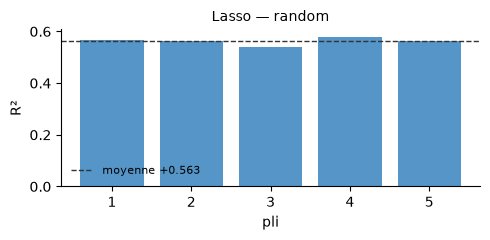

In [20]:
run_cv(build(encode(scale=True),
             PolynomialFeatures(2, interaction_only=True, include_bias=False),
             Lasso(alpha=0.01)),
       "Lasso — random", X_train, y_train, groups_train,cv=KFold(5, shuffle=True, random_state=RANDOM_STATE))


## <a id='toc6_1_'></a>[RandomForest](#toc0_)

c:\Users\Kevin\projects\OC_P12\.venv\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
2026/08/11 18:48:14 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary

RandomForest — grouped R2 = +0.480 ± 0.088   RMSE = 5.60 t/ha
🏃 View run RandomForest — grouped at: http://127.0.0.1:5000/#/experiments/1/runs/49f5635865234f40bf49fbd676a86311
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


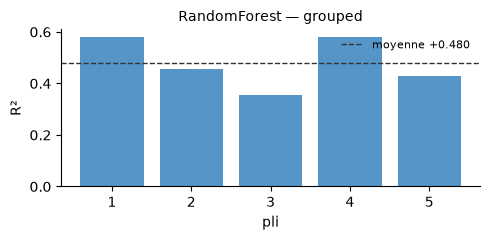

In [21]:
run_cv(build(encode(),
             RandomForestRegressor(n_estimators=300, min_samples_leaf=5,
                                   random_state=RANDOM_STATE, n_jobs=-1)),
       "RandomForest — grouped", X_train, y_train, groups_train)


c:\Users\Kevin\projects\OC_P12\.venv\Lib\site-packages\sklearn\model_selection\_split.py:86: UserWarning: The groups parameter is ignored by KFold
  warnings.warn(
c:\Users\Kevin\projects\OC_P12\.venv\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
2026/08/11 18:48:21 WARNING mlflow.sklearn: Saving scikit-learn model

RandomForest — random  R2 = +0.932 ± 0.007   RMSE = 2.03 t/ha
🏃 View run RandomForest — random at: http://127.0.0.1:5000/#/experiments/1/runs/d388dd2200b94d99810d72743e3af9dc
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


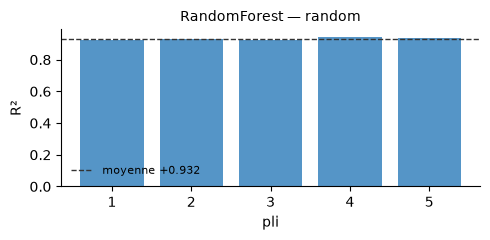

In [22]:
run_cv(build(encode(),
             RandomForestRegressor(n_estimators=300, min_samples_leaf=5,
                                   random_state=RANDOM_STATE, n_jobs=-1)),
       "RandomForest — random", X_train, y_train, groups_train, cv=KFold(5, shuffle=True, random_state=RANDOM_STATE))

## <a id='toc6_1_'></a>[HistGradientBoostingRegressor](#toc0_)

c:\Users\Kevin\projects\OC_P12\.venv\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
2026/08/11 18:48:26 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary

HistGB — grouped       R2 = +0.566 ± 0.105   RMSE = 5.11 t/ha
🏃 View run HistGB — grouped at: http://127.0.0.1:5000/#/experiments/1/runs/519f2a3f94134155b7e1c482d6bae53f
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


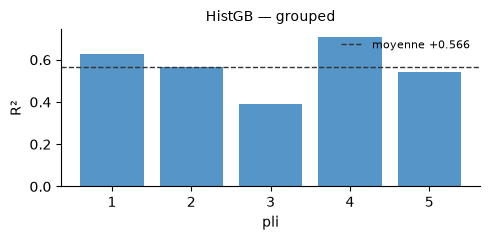

In [23]:
run_cv(build(HistGradientBoostingRegressor(early_stopping=False, random_state=RANDOM_STATE)),
       "HistGB — grouped", X_train, y_train, groups_train)

c:\Users\Kevin\projects\OC_P12\.venv\Lib\site-packages\sklearn\model_selection\_split.py:86: UserWarning: The groups parameter is ignored by KFold
  warnings.warn(
c:\Users\Kevin\projects\OC_P12\.venv\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
2026/08/11 18:48:30 WARNING mlflow.sklearn: Saving scikit-learn model

HistGB — random        R2 = +0.889 ± 0.010   RMSE = 2.60 t/ha
🏃 View run HistGB — random at: http://127.0.0.1:5000/#/experiments/1/runs/883be51a5edd4f23958ca0ef54a25663
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


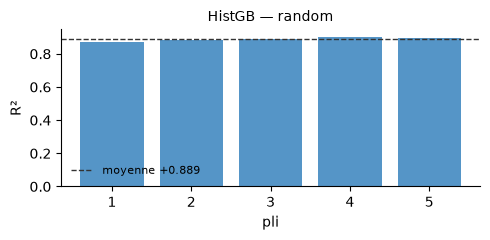

In [24]:
run_cv(build(HistGradientBoostingRegressor(early_stopping=False, random_state=RANDOM_STATE)),
       "HistGB — random", X_train, y_train, groups_train, cv=KFold(5, shuffle=True, random_state=RANDOM_STATE))

In [25]:
temporel = [(np.where(X_train["Year"] <= 2008)[0], np.where(X_train["Year"] > 2008)[0])]

run_cv(build(HistGradientBoostingRegressor(early_stopping=False, random_state=RANDOM_STATE)),
       "HistGB — temporal", X_train, y_train, groups_train, cv=temporel,
       tags={"cv": "temporal"})


c:\Users\Kevin\projects\OC_P12\.venv\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
2026/08/11 18:48:33 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary

HistGB — temporal      R2 = +0.835 ± 0.000   RMSE = 3.48 t/ha
🏃 View run HistGB — temporal at: http://127.0.0.1:5000/#/experiments/1/runs/4611cfef4f424bbd874735edc1d3b5d9
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


## <a id='toc6_1_'></a>[CatBoostRegressor](#toc0_)

c:\Users\Kevin\projects\OC_P12\.venv\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
2026/08/11 18:48:44 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary

CatBoost — grouped     R2 = +0.533 ± 0.128   RMSE = 5.29 t/ha
🏃 View run CatBoost — grouped at: http://127.0.0.1:5000/#/experiments/1/runs/21c6f21aa73343ad9fd212ffd85a16c8
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


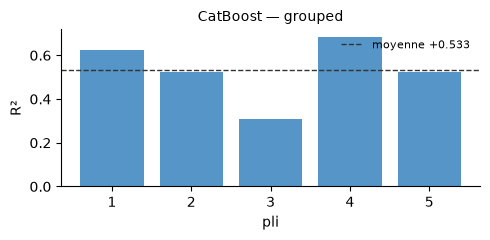

In [26]:
run_cv(build(encode(),
             CatBoostRegressor(random_state=RANDOM_STATE,
                               verbose=0, allow_writing_files=False)),
       "CatBoost — grouped", X_train, y_train, groups_train)


c:\Users\Kevin\projects\OC_P12\.venv\Lib\site-packages\sklearn\model_selection\_split.py:86: UserWarning: The groups parameter is ignored by KFold
  warnings.warn(
c:\Users\Kevin\projects\OC_P12\.venv\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
2026/08/11 18:48:55 WARNING mlflow.sklearn: Saving scikit-learn model

CatBoost — random      R2 = +0.918 ± 0.005   RMSE = 2.24 t/ha
🏃 View run CatBoost — random at: http://127.0.0.1:5000/#/experiments/1/runs/c073e9d1f5734933b6985ea07b5c8bac
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


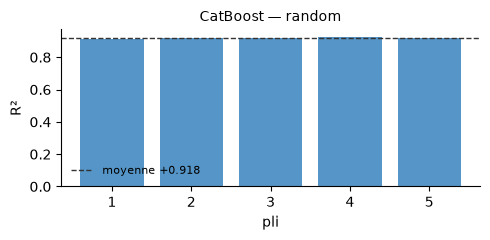

In [27]:
run_cv(build(encode(),
             CatBoostRegressor(random_state=RANDOM_STATE,
                               verbose=0, allow_writing_files=False)),
       "CatBoost — random", X_train, y_train, groups_train, cv=KFold(5, shuffle=True, random_state=RANDOM_STATE))


In [28]:
temporel = [(np.where(X_train["Year"] <= 2008)[0], np.where(X_train["Year"] > 2008)[0])]

run_cv(build(encode(),
             CatBoostRegressor(random_state=RANDOM_STATE,
                               verbose=0, allow_writing_files=False)),
       "CatBoost — temporal", X_train, y_train, groups_train, cv=temporel,
       tags={"cv": "temporal"})

c:\Users\Kevin\projects\OC_P12\.venv\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
2026/08/11 18:49:01 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary

CatBoost — temporal    R2 = +0.858 ± 0.000   RMSE = 3.23 t/ha
🏃 View run CatBoost — temporal at: http://127.0.0.1:5000/#/experiments/1/runs/4ef538d8b993429b9e52c0721b84f8dd
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


# <a id='toc5_'></a>[Recap Benchmark](#toc0_)

,R² groupé,R² aléatoire,RMSE groupé,RMSE aléatoire,mémorisation
modele,,,,,
HistGB optimisé,0.595,NaN,4.943,NaN,NaN
HistGB,0.566,0.889,5.106,2.600,1.964
CatBoost,0.533,0.918,5.286,2.238,2.363
RandomForest,0.480,0.932,5.601,2.030,2.759
Ridge,0.415,0.594,5.862,4.979,1.177
Lasso,0.412,0.563,5.871,5.166,1.137
Dummy,-0.164,-0.160,8.393,8.418,0.997


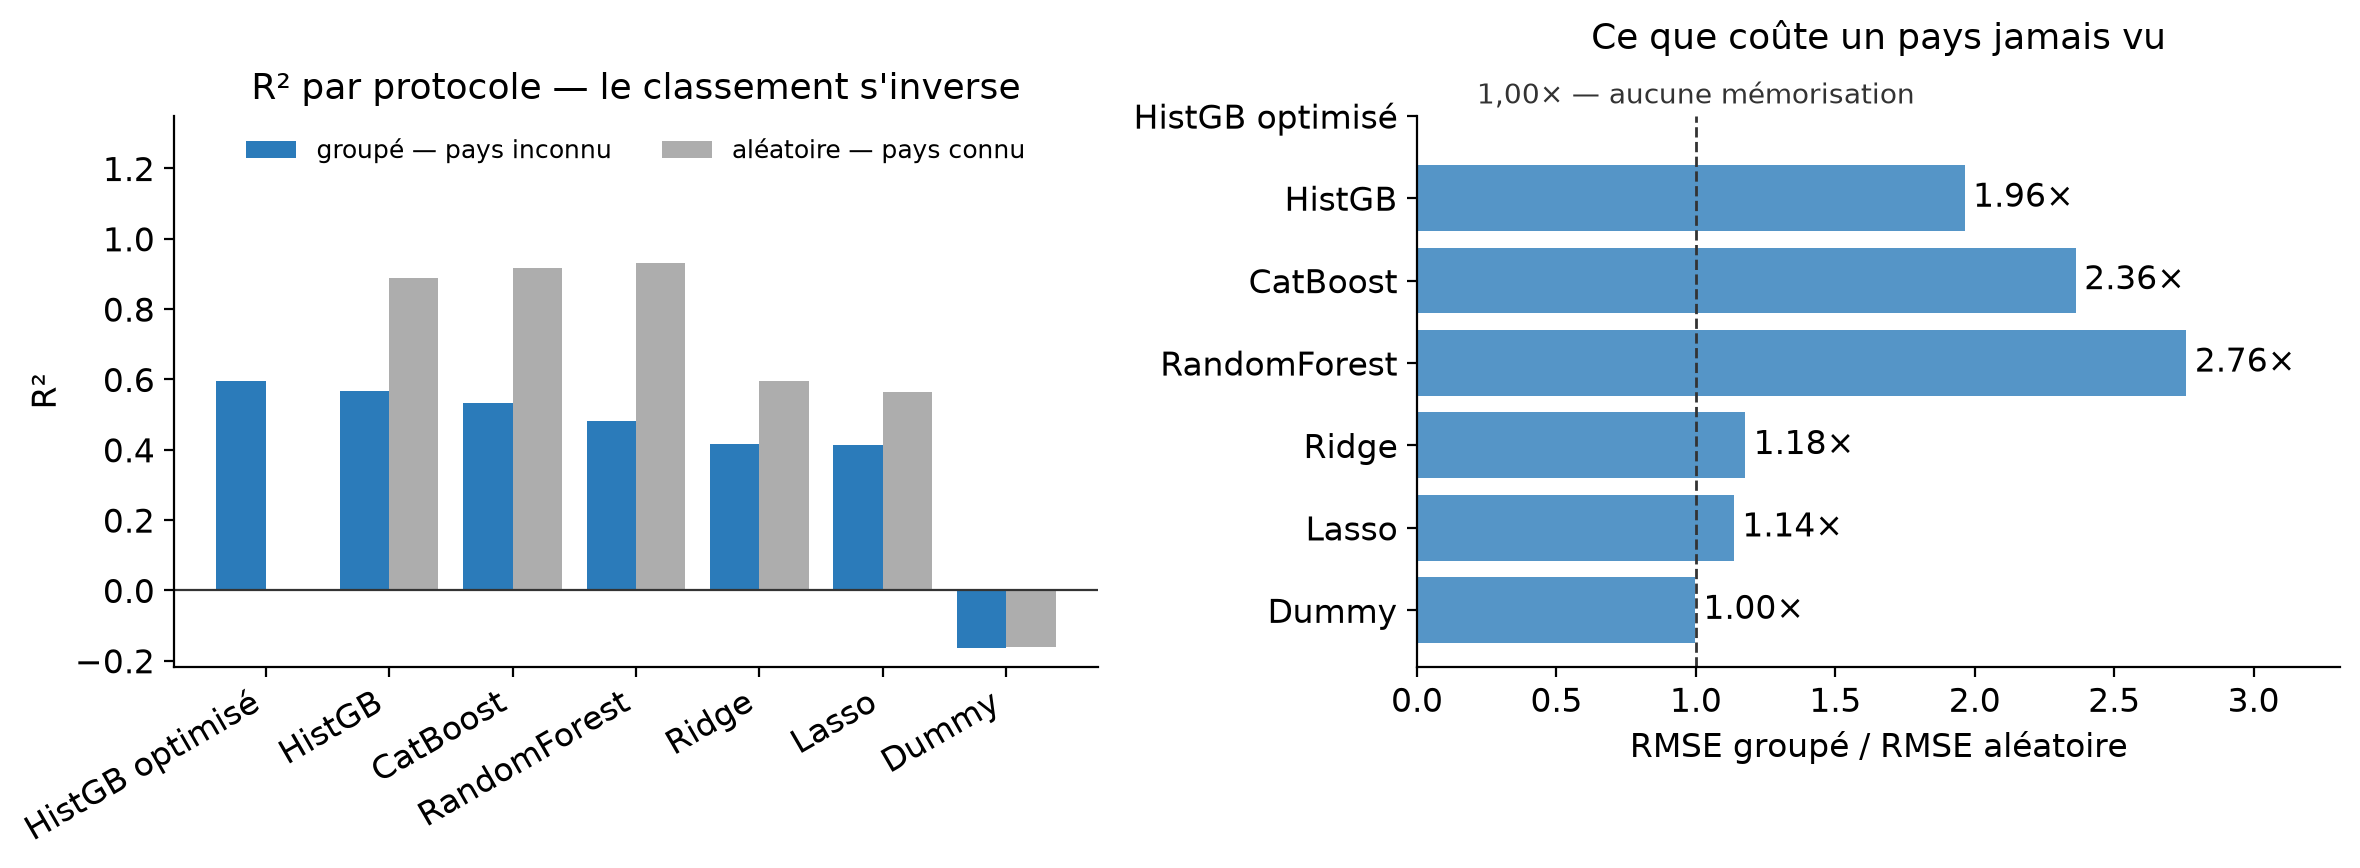

In [29]:
# Read the benchmark straight from MLflow: no number retyped here, and nothing to
# resync if a model is rerun. The run name carries both axes we need.
runs = mlflow.search_runs(experiment_names=[EXPERIMENT_NAME])
runs[["modele", "protocole"]] = runs["tags.mlflow.runName"].str.split(" — ", n=1, expand=True)

PROTOCOLES = {"grouped": "groupé", "random": "aléatoire"}

# Two independent levers, often confused: dpi only buys sharpness, font size is what fixes
# "too small to read" -- the notebook shrinks a 12in figure to fit the cell either way.
# Scoped with rc_context so run_cv's per-fold charts keep their own settings.
QUALITE = {"figure.dpi": 200, "savefig.dpi": 200,
           "font.size": 12, "axes.titlesize": 13, "legend.fontsize": 11}


def table(metric):
    """One row per model, one column per protocol.

    Indexed on the run name rather than tags.model_family: it reads "HistGB" instead of
    "HistGradientBoostingRegressor", and it keeps future ablation runs on their own row
    instead of colliding with the Phase A run of the same estimator.
    """
    return (runs[runs["protocole"].isin(PROTOCOLES)]
            .pivot(index="modele", columns="protocole", values=f"metrics.{metric}")
            .rename(columns=PROTOCOLES))


r2 = table("r2_mean").sort_values("groupé", ascending=False)   # the grouped protocol decides
rmse = table("rmse_mean").loc[r2.index]

# How much worse a model gets on a country it has never seen. RMSE and not R2: the two
# protocols score on different test sets, so their R2 denominators differ -- only an
# absolute error compares across them. The Dummy sits at 1.00 and calibrates the scale.
memorisation = rmse["groupé"] / rmse["aléatoire"]

with plt.rc_context(QUALITE):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
    x = np.arange(len(r2))

    ax1.bar(x - 0.2, r2["groupé"], 0.4, color=BLUE, label="groupé — pays inconnu")
    ax1.bar(x + 0.2, r2["aléatoire"], 0.4, color=INK, alpha=0.4, label="aléatoire — pays connu")
    ax1.axhline(0, color=INK, lw=0.8)
    ax1.set_xticks(x, r2.index, rotation=30, ha="right")
    ax1.set_ylim(top=1.35)                     # clearance for the legend above the bars
    ax1.set_ylabel("R²")
    ax1.set_title("R² par protocole — le classement s'inverse")
    # One row, centred: stacked on two lines it crowded the tallest bars.
    ax1.legend(loc="upper center", ncols=2, frameon=False, fontsize=9)

    bars = ax2.barh(x, memorisation, color=BLUE, alpha=0.8)
    ax2.bar_label(bars, fmt="%.2f×", padding=3)
    ax2.axvline(1, color=INK, ls="--", lw=1)
    # Annotated on the line itself: a legend box for a single reference line ate the
    # bottom-right corner, right where the Dummy bar and its label already sit.
    ax2.text(1, 1.01, "1,00× — aucune mémorisation", transform=ax2.get_xaxis_transform(),
             ha="center", va="bottom", fontsize=10, color=INK)
    ax2.set_yticks(x, memorisation.index)
    ax2.invert_yaxis()
    ax2.set_xlim(0, memorisation.max() * 1.2)
    ax2.set_xlabel("RMSE groupé / RMSE aléatoire")
    ax2.set_title("Ce que coûte un pays jamais vu", pad=24)

    sns.despine(fig=fig)
    fig.tight_layout()

    # Explicit export for the report: right-click-save would only give the inline render.
    FIGURES = Path("../figures")
    FIGURES.mkdir(exist_ok=True)
    fig.savefig(FIGURES / "recap_benchmark.png", bbox_inches="tight")

pd.DataFrame({"R² groupé": r2["groupé"], "R² aléatoire": r2["aléatoire"],
              "RMSE groupé": rmse["groupé"], "RMSE aléatoire": rmse["aléatoire"],
              "mémorisation": memorisation}).round(3)

### Ce que le benchmark établit

- **Le classement s'inverse entre protocoles** : RandomForest, premier en aléatoire (0,93), tombe troisième en groupé (0,48) ; HistGB fait le trajet inverse. Une sélection en CV aléatoire aurait retenu le modèle qui généralise **le plus mal** aux pays inconnus.
- **Le Dummy valide la comparaison** : 8,39 t/ha en groupé contre 8,42 en aléatoire (0,3 % d'écart) — les deux jeux de test sont de difficulté équivalente, la chute 0,93 → 0,48 de RF est donc réelle et ne vient pas du dénominateur du R².
- **Le rapport des RMSE mesure la mémorisation** : 1,00× pour le Dummy qui ne peut rien mémoriser, ~1,15× pour les linéaires, 2 à 2,8× pour les arbres — plus un modèle est flexible, plus il apprend l'empreinte climatique du pays par cœur.
- **Finaliste : HistGB** — meilleur R² groupé (0,566) et le plus stable d'un pli à l'autre.

# <a id='toc5_'></a>[Optimisation HistGB](#toc0_)

In [30]:
# Regularisation first: 14 371 rows but only 109 effective climate profiles, so the risk
# here is overfitting the country, not underfitting the signal.

P = "regressor__histgradientboostingregressor__"   # path through TransformedTargetRegressor
GRILLE = {
    P + "max_leaf_nodes": [15, 31, 63, 127],
    P + "min_samples_leaf": [20, 50, 100, 200],
    P + "l2_regularization": [0.0, 0.1, 1.0, 10.0],
    P + "learning_rate": [0.03, 0.05, 0.1, 0.2],
    P + "max_iter": [100, 300, 500],
}

recherche = RandomizedSearchCV(
    build(HistGradientBoostingRegressor(early_stopping=False, random_state=RANDOM_STATE)),
    GRILLE,
    n_iter=40,
    cv=GroupKFold(n_splits=5),   # never KFold here: a random CV would select the setup
    scoring="r2",                # that memorises the country fingerprint best
    n_jobs=-1,
    random_state=RANDOM_STATE,
)

# autolog turns the search into a parent run plus a child run per best candidate (5 by
# default) and writes cv_results_ as an artifact -- all of it for free.
#
# log_models=False is NOT optional: autolog serialises with skops, which cannot reload our
# custom inverse_func. It would write an artifact that only fails at load time, i.e. at
# deployment. The winner is logged below by run_cv, which forces cloudpickle.
mlflow.sklearn.autolog(log_models=False, log_datasets=False)
delete_run_if_exists(EXPERIMENT_NAME, "HistGB — recherche HPO")
try:
    with mlflow.start_run(run_name="HistGB — recherche HPO"):
        # groups= is what GroupKFold splits on -- without it the search raises.
        recherche.fit(X_train, y_train, groups=groups_train)
finally:
    # autolog is a global switch: left on, it would double-log every later run_cv call.
    mlflow.sklearn.autolog(disable=True)

print(f"meilleur R² sous GroupKFold : {recherche.best_score_:+.3f}\n")
for cle, valeur in recherche.best_params_.items():
    print(f"   {cle.removeprefix(P):<20} {valeur}")

2026/08/11 18:49:20 INFO mlflow.sklearn.utils: Logging the 5 best runs, 35 runs will be omitted.
2026/08/11 18:49:20 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "c:\Users\Kevin\projects\OC_P12\.venv\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."


🏃 View run valuable-loon-403 at: http://127.0.0.1:5000/#/experiments/1/runs/46c8fecfa1674ffaa3f6ff4f050b32dc
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1
🏃 View run secretive-yak-389 at: http://127.0.0.1:5000/#/experiments/1/runs/da8515703f874bae9b58e95c7c9ff323
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1
🏃 View run victorious-lark-507 at: http://127.0.0.1:5000/#/experiments/1/runs/6a147683ce724c21899ba61a38f32ba5
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1
🏃 View run valuable-frog-546 at: http://127.0.0.1:5000/#/experiments/1/runs/7fedb798dbd64229bee29cb76f709efc
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1
🏃 View run exultant-shark-259 at: http://127.0.0.1:5000/#/experiments/1/runs/d141480d0ea9486492a4bb245fddea6d
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1
🏃 View run HistGB — recherche HPO at: http://127.0.0.1:5000/#/experiments/1/runs/1ba16f84a7ff4136a2ee4e478058b5b9
🧪 View experiment at: http://127.0.0.1

c:\Users\Kevin\projects\OC_P12\.venv\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
2026/08/11 18:49:21 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary

HistGB optimisé — grouped R2 = +0.595 ± 0.078   RMSE = 4.94 t/ha
🏃 View run HistGB optimisé — grouped at: http://127.0.0.1:5000/#/experiments/1/runs/9b49e0b05c85436c9f743b6c6e174328
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


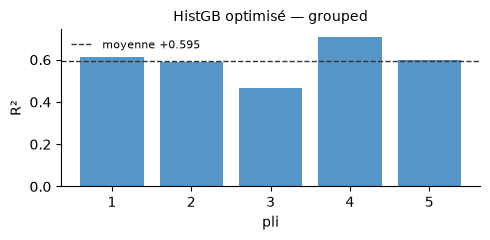

In [31]:
# Back through run_cv so the tuned model lands in the benchmark table with the same metrics
# and the same protocol as the others -- and on its own row in the recap chart, which keys
# on the run name rather than on the estimator class.
run_cv(recherche.best_estimator_, "HistGB optimisé — grouped", X_train, y_train, groups_train)

### Ce que l'optimisation établit

- **C'est la régularisation qui gagne** : la recherche retient presque partout le choix le plus contraint de la grille (15 feuilles, L2 = 10, 100 itérations). Cohérent avec le risque identifié — 14 371 lignes mais 109 profils climatiques effectifs : le danger est d'apprendre le pays par cœur, pas de manquer de signal.
- Gain : R² groupé 0,566 → **0,595** (RMSE 5,11 → 4,94 t/ha). Modeste et attendu — l'optimisation ne crée pas d'information, elle limite le sur-apprentissage.

In [10]:
# RESUME POINT -- on a fresh kernel, run only: imports, data, clean_data, the split, the
# split checks and the MLflow config, then this cell. Then SKIP the "test final" cell:
# it needs `recherche` from the search and would re-log its MLflow run. Everything after
# it needs only the fitted model and y_pred, both rebuilt here -- reloading costs ~1.5 s
# against several minutes for RandomizedSearchCV.
#
# No-op on a full top-to-bottom run: `recherche` exists then, and the next cell rebuilds
# both names from it. The guard also keeps the notebook runnable with no MLflow server up.
def charger_modele(nom="modele_final"):
    """Fetch the model already logged, by name rather than by a hardcoded id.

    MLflow 3 stores models as entities of their own, not as run artifacts, so the URI is
    models:/<model_id>. Deleting a run leaves its logged model behind, so re-running the
    evaluation cell leaves several candidates under the same name -- hence the filter on
    the source run still being active. The tuple unpacking asserts there is exactly one.
    """
    client = MlflowClient()
    exp = client.get_experiment_by_name(EXPERIMENT_NAME)
    (modele,) = [m for m in client.search_logged_models(experiment_ids=[exp.experiment_id])
                 if m.name == nom
                 and client.get_run(m.source_run_id).info.lifecycle_stage == "active"]
    return mlflow.sklearn.load_model(f"models:/{modele.model_id}")


if "recherche" not in globals():
    modele_final = charger_modele()
    y_pred = modele_final.predict(X_test)
    print(f"modèle rechargé · RMSE {root_mean_squared_error(y_test, y_pred):.2f} t/ha "
          f"· R² {r2_score(y_test, y_pred):+.3f}")

modèle rechargé · RMSE 4.94 t/ha · R² +0.627


# <a id='toc5_'></a>[Évaluation finale sur le jeu de test](#toc0_)

In [32]:
# The one and only pass on the test set: 22 countries the model has never seen. No choice
# is arbitrated on these numbers -- if they disappoint, they get reported as they are.
modele_final = recherche.best_estimator_        # RandomizedSearchCV already refit it on X_train
y_pred = modele_final.predict(X_test)

metriques_test = {
    "test_rmse": root_mean_squared_error(y_test, y_pred),
    "test_mae": mean_absolute_error(y_test, y_pred),
    "test_r2": r2_score(y_test, y_pred),
}

# Its own run rather than run_cv: this is a single holdout, not a cross-validation, so
# there are no folds to average and no r2_std to report. The tag cv="holdout" keeps it out
# of the recap chart, which only picks up the grouped and random protocols.
delete_run_if_exists(EXPERIMENT_NAME, "HistGB optimisé — test final")
with mlflow.start_run(run_name="HistGB optimisé — test final"):
    mlflow.log_params({cle.removeprefix(P): val for cle, val in recherche.best_params_.items()})
    mlflow.log_metrics(metriques_test)
    mlflow.set_tag("cv", "holdout")
    mlflow.set_tag("model_family", type(modele_final.regressor.steps[-1][1]).__name__)
    log_model(modele_final, "modele_final", X_test.head(5))

print(f"{len(X_test)} lignes · {groups_test.nunique()} pays jamais vus\n")
print(f"RMSE  {metriques_test['test_rmse']:5.2f} t/ha")
print(f"MAE   {metriques_test['test_mae']:5.2f} t/ha")
print(f"R²    {metriques_test['test_r2']:+.3f}")

c:\Users\Kevin\projects\OC_P12\.venv\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
2026/08/11 18:49:24 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary

🏃 View run HistGB optimisé — test final at: http://127.0.0.1:5000/#/experiments/1/runs/304c0d8da1f34eb89cb3292070767a50
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1
2821 lignes · 22 pays jamais vus

RMSE   4.94 t/ha
MAE    2.85 t/ha
R²    +0.627


### Ce que le test final établit

- **RMSE 4,94 t/ha · MAE 2,85 t/ha · R² +0,627**, sur 2 821 lignes de 22 pays jamais vus. Un seul passage, aucun réglage effectué dessus.
- Le R² de test (0,627) dépasse celui de la validation croisée (0,595) : les 22 pays tirés au sort sont simplement un peu plus faciles que la moyenne des plis. Variance d'échantillonnage, pas fuite.
- L'écart entre RMSE (4,94) et MAE (2,85) signale que **quelques grosses erreurs dominent** — les cellules suivantes cherchent lesquelles.

In [33]:
def rmsle(vrai, predit):
    """Root mean squared error in log space -- a relative error by construction.

    Deliberately NOT sklearn's root_mean_squared_log_error: that one computes on log(1 + y),
    and the +1 crushes our smallest yields (min 0.005 t/ha). A factor-2 error on a low-yield
    crop would come out as nearly zero -- precisely what this table exists to reveal. Our
    target is strictly positive, so the +1 protects against nothing here.
    """
    return np.sqrt(np.mean((np.log(vrai) - np.log(predit)) ** 2))


# A per-crop RMSE in t/ha would reproduce the very bias we are testing for: 4 t/ha of error
# is 25 % on potatoes (16 t/ha median) but over 300 % on sorghum (1.26). A difference of logs
# is a ratio, so it is scale-free -- and it is what the model actually minimises, since it
# trains on log(y). exp() turns it back into a readable error FACTOR.
detail = pd.DataFrame({"culture": X_test["Item"].values,
                       "vrai": y_test.values,
                       "predit": y_pred})

# Computed here, not in a later cell: rebuilding `detail` would silently drop any column
# added downstream, and both diagnostic cells below read this one.
detail["ecart_log"] = np.log(detail["vrai"]) - np.log(detail["predit"])

lignes = []
for culture, groupe in detail.groupby("culture", observed=True):
    erreur_log = rmsle(groupe["vrai"], groupe["predit"])
    lignes.append({
        "culture": culture,
        "n test": len(groupe),
        "médiane t/ha": groupe["vrai"].median(),
        "RMSE t/ha": root_mean_squared_error(groupe["vrai"], groupe["predit"]),
        "RMSLE": erreur_log,
        # A factor, deliberately not a percentage: a log error is symmetric as a RATIO.
        # "±229 %" would claim an impossible error, since a percentage floors at -100 %;
        # the true band for RMSLE=1.19 is +229 % up but only -70 % down. x3,29 reads
        # correctly both ways -- predictions land between vrai/3,29 and vrai*3,29.
        "facteur typique": np.exp(erreur_log),
    })

# Read n test alongside every figure: coverage is very uneven, and a metric computed on a
# few dozen rows is noise dressed up as a number.
par_culture = pd.DataFrame(lignes).sort_values("RMSLE").set_index("culture")
par_culture.round(3)

,n test,médiane t/ha,RMSE t/ha,RMSLE,facteur typique
culture,,,,,
Plantains and others,46,10.061,1.891,0.235,1.265
Yams,115,6.393,3.756,0.351,1.421
"Rice, paddy",299,3.402,1.999,0.478,1.613
Potatoes,478,14.892,8.300,0.523,1.688
Cassava,138,9.273,8.662,0.570,1.767
Maize,488,3.101,2.118,0.643,1.903
Sorghum,321,1.012,1.335,0.721,2.057
Wheat,442,2.554,2.244,0.730,2.075
Sweet potatoes,253,8.363,8.283,0.984,2.674


### Ce que ce tableau établit

**Hypothèse** — un RMSE en t/ha classerait les cultures par leur tonnage plutôt que par la qualité du modèle. Une erreur relative doit inverser ce classement.

**Exemple** — Soybeans : 0,79 t/ha d'erreur, le **meilleur** score en tonnes, mais une RMSLE de 1,192, le **pire** en relatif. Potatoes fait l'inverse : 8,30 t/ha (9ᵉ) pour une RMSLE de 0,523 (4ᵉ), sa médiane étant à 14,9 t/ha.

**Conclusions**

- Le classement **s'inverse**. Publier un RMSE par culture aurait donné la conclusion opposée sur la moitié des cultures.
- Les facteurs d'erreur s'étalent de **×1,26 à ×3,29** : le passage au log n'a **pas** homogénéisé les erreurs relatives, contrairement à ce qui était espéré.
- Les niveaux absolus ne sont pas encore interprétables : une moyenne de carrés peut être portée par une poignée de lignes. C'est l'objet de la cellule suivante.

In [34]:
# World reference per crop, over all 109 countries: the level the model falls back on when
# it knows nothing about a country. Read by the tail cell below.
mediane_monde = df_clean.groupby("Item", observed=True)["yield_t_per_ha"].median()

# The RMSLE hides two very different failures behind one number. With
#     d = ln(vrai) - ln(prédit)        (d > 0 means the model UNDER-estimates)
# the identity E[d²] = E[d]² + Var(d) splits it exactly:
#     RMSLE² = biais² + σ²
# A systematic offset and a random scatter give the same RMSLE and call for opposite
# answers -- a bias is correctable, a dispersion is not. `ecart_log` is built with `detail`.

lignes = []
for culture, groupe in detail.groupby("culture", observed=True):
    d = groupe["ecart_log"]
    rmsle_c = np.sqrt(np.mean(d**2))
    lignes.append({
        "culture": culture,
        "n": len(d),
        "RMSLE": rmsle_c,
        "médiane |d|": d.abs().median(),
        # Squaring hands all the weight to the worst rows. A ratio near 1 means the model is
        # evenly mediocre; a large ratio means a handful of disasters carry the whole score,
        # which is a different diagnosis and a different fix.
        "RMSLE / médiane": rmsle_c / d.abs().median(),
        "biais": d.mean(),
        "σ": d.std(ddof=0),
        "sous-estime ×": np.exp(d.mean()),
    })

diagnostic = pd.DataFrame(lignes).set_index("culture").sort_values("RMSLE")

# _clipped_exp bounds every prediction to the yields seen during training. A prediction
# sitting on a bound is an extrapolation the model could not make on an unknown country --
# and a log error guaranteed to be large.
plancher, plafond = np.exp(LOG_MIN), np.exp(LOG_MAX)
au_plancher = int((y_pred <= plancher * 1.001).sum())
au_plafond = int((y_pred >= plafond * 0.999).sum())
print(f"bornes de _clipped_exp : {plancher:.3f} — {plafond:.1f} t/ha")
print(f"prédictions bloquées   : {au_plancher} au plancher, {au_plafond} au plafond, "
      f"sur {len(y_pred)} lignes\n")

diagnostic.round(3)

bornes de _clipped_exp : 0.058 — 49.6 t/ha
prédictions bloquées   : 0 au plancher, 0 au plafond, sur 2821 lignes



,n,RMSLE,médiane |d|,RMSLE / médiane,biais,σ,sous-estime ×
culture,,,,,,,
Plantains and others,46,0.235,0.195,1.206,0.114,0.205,1.121
Yams,115,0.351,0.231,1.521,-0.079,0.342,0.924
"Rice, paddy",299,0.478,0.397,1.203,0.155,0.452,1.168
Potatoes,478,0.523,0.392,1.336,-0.057,0.520,0.945
Cassava,138,0.570,0.242,2.358,0.158,0.547,1.171
Maize,488,0.643,0.396,1.626,0.003,0.643,1.003
Sorghum,321,0.721,0.443,1.627,-0.098,0.714,0.906
Wheat,442,0.730,0.438,1.667,0.163,0.711,1.177
Sweet potatoes,253,0.984,0.554,1.776,-0.090,0.980,0.914


### Ce que ce diagnostic établit

**Hypothèse** — une même RMSLE peut cacher trois situations très différentes : un modèle mauvais partout, un modèle bon sauf quelques désastres, ou un modèle qui se trompe toujours dans le même sens. Deux colonnes les séparent : la **médiane |d|** (l'erreur sur une ligne ordinaire) et le **biais** (se trompe-t-il toujours dans le même sens ?).

**Exemple** — Soybeans : pire RMSLE du tableau (1,19), mais sur une ligne ordinaire il ne se trompe que de ×1,30 — la 4ᵉ meilleure médiane. Sa mauvaise note vient d'une poignée de lignes catastrophiques, pas d'une faiblesse générale.

**Conclusions**

- **Deux façons d'échouer, à ne pas confondre.** Soybeans et Cassava : bons d'habitude, désastreux parfois — leur RMSLE est portée par quelques lignes (rapport RMSLE / médiane de 4,5 et 2,4). Wheat, Sorghum et Sweet potatoes : médiocres partout, ×1,5 à ×1,7 d'erreur sur une ligne ordinaire.
- **Pas de décalage systématique** : le modèle ne sur-estime ni ne sous-estime une culture en bloc (biais proche de zéro presque partout). Conséquence concrète : aucune correction simple du type « +20 % sur telle culture » n'améliorerait les prédictions — l'erreur est de la dispersion, pas un décalage.
- **Le garde-fou `_clipped_exp` n'est jamais touché** (0 prédiction bloquée sur 2 821) : ces erreurs sont bien celles du modèle, pas un artefact du bornage.

In [35]:
# Nothing hit the _clipped_exp bounds, so the tail is genuine model output, not a clamp.
# Hypothesis to test: the model, knowing nothing about a country it never saw, predicts the
# world norm for the crop -- so the worst rows should be countries far away from that norm.
detail["pays"] = groups_test.values      # same row order: detail was built from .values
detail["annee"] = X_test["Year"].values

# Heavy-tailed crops, picked by the data rather than by hand: 1.48 is the RMSLE/median ratio
# of normally distributed log errors, so anything past 2 has a tail worth opening.
a_queue = diagnostic.index[diagnostic["RMSLE / médiane"] > 2].tolist()

for culture in a_queue:
    g = detail[detail["culture"] == culture]
    pires = g.loc[g["ecart_log"].abs().nlargest(10).index]
    part = (pires["ecart_log"] ** 2).sum() / (g["ecart_log"] ** 2).sum()

    print(f"\n{'=' * 78}\n{culture} — {len(g)} lignes, médiane {g['vrai'].median():.2f} t/ha")
    print(f"les 10 pires lignes portent {part:.0%} de l'erreur quadratique de la culture\n")
    print(pires.assign(facteur=np.exp(pires["ecart_log"].abs()))
               [["pays", "annee", "vrai", "predit", "ecart_log", "facteur"]]
          .round(2).to_string(index=False))

    # The country carrying the tail, put against the WORLD median rather than against the
    # other test countries: a rank says who is worst, a ratio says how far from normal --
    # and it is the distance from normal that the hypothesis is about.
    porteur = g.groupby("pays")["ecart_log"].apply(lambda d: (d ** 2).sum()).idxmax()
    gp = g[g["pays"] == porteur]
    monde = mediane_monde[culture]
    part_pays = (gp["ecart_log"] ** 2).sum() / (g["ecart_log"] ** 2).sum()

    print(f"\n  {porteur} — {len(gp)} lignes, {part_pays:.0%} de l'erreur de la culture")
    print(f"    médiane mondiale   {monde:7.2f} t/ha")
    print(f"    rendement réel     {gp['vrai'].median():7.2f} t/ha"
          f"   ×{gp['vrai'].median() / monde:.2f} la norme")
    print(f"    prédiction         {gp['predit'].median():7.2f} t/ha"
          f"   ×{gp['predit'].median() / monde:.2f} la norme  <- le modèle prédit la norme")


Cassava — 138 lignes, médiane 9.27 t/ha
les 10 pires lignes portent 42% de l'erreur quadratique de la culture

 pays  annee  vrai  predit  ecart_log  facteur
India   2008 33.54    7.33       1.52     4.58
India   2012 38.58    8.68       1.49     4.44
India   2011 36.48    8.68       1.44     4.20
India   2013 34.96    8.88       1.37     3.94
India   2010 34.76    8.88       1.36     3.92
India   2009 34.34    8.90       1.35     3.86
India   2006 32.11    8.47       1.33     3.79
India   2007 32.22    8.51       1.33     3.79
India   2005 30.50    8.47       1.28     3.60
India   1995 25.28    7.17       1.26     3.52

  India — 23 lignes, 82% de l'erreur de la culture
    médiane mondiale     10.00 t/ha
    rendement réel       26.91 t/ha   ×2.69 la norme
    prédiction            7.79 t/ha   ×0.78 la norme  <- le modèle prédit la norme

Soybeans — 241 lignes, médiane 1.22 t/ha
les 10 pires lignes portent 69% de l'erreur quadratique de la culture

      pays  annee  vrai  predit  e

### Ce que cette analyse établit

**Hypothèse** — sans information de pays, le modèle ne s'eloigne pas trop de la norme mondiale de la culture. Les pires lignes devraient donc venir de pays dont le rendement réel s'en écarte fortement.

**Exemple**

| culture | pays | médiane monde | réel |  prédit | 
|---|---|---|---|---|
| Cassava | Inde | 10,0  | 26,9 | 7,8 | 
| Soybeans | Tadjikistan | 1,62  | 0,03 | 1,55 | 

**Conclusions**

- **Hypothèse confirmée.** Le modèle prédit à peu près la médiane mondiale dans les deux cas (×0,78 et ×0,96) ; c'est le **pays** qui est atypique. Un seul pays porte 90 % de l'erreur de Soybeans et un autre 80 % de celle de Cassava.
- **Même structure des deux côtés** : une seule culture décroche, toutes les autres du pays sont normales — 7 cultures indiennes entre ×0,64 et ×1,16, 5 tadjikes entre ×0,74 et ×1,49. Ce n'est jamais un problème de pays, toujours un couple pays-culture.
- **Limite à retenir.** Une RMSLE par culture sur ~240 lignes n'est pas robuste : un pays atypique la domine. Sans le Tadjikistan, celle de Soybeans tomberait de 1,19 à ≈ 0,39. Publier la médiane à côté.

# <a id='toc5_'></a>[Interprétation](#toc0_)

In [ ]:
# How much accuracy is lost when a column is scrambled. Measured on the grouped test set --
# unseen countries, which is where the question matters -- and scored in log space, because
# that is the space the model optimises and it keeps every crop on the same footing.
def score_log(estimateur, X, y):
    """Negative RMSLE: permutation_importance maximises, so higher has to mean better."""
    return -np.sqrt(np.mean((np.log(y) - np.log(estimateur.predict(X))) ** 2))


importance = permutation_importance(
    modele_final, X_test, y_test,
    scoring=score_log, n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1,
)

# Read as "RMSLE points lost when this column is destroyed". A value near zero means the
# model was not using the column -- which, for a climate column, decides whether /recommend
# can react to context at all.
pd.DataFrame({"variable": X_test.columns,
              "perte RMSLE": importance.importances_mean,
              "σ": importance.importances_std}
             ).sort_values("perte RMSLE", ascending=False).set_index("variable").round(4)

,perte RMSLE,σ
variable,,
Item,0.7089,0.0094
pesticides_kg_per_ha,0.1206,0.0068
avg_temp,0.0329,0.0021
Year,0.0079,0.0010
average_rain_fall_mm_per_year,-0.0039,0.0026


### Ce que la permutation importance établit

Permuter une colonne détruit son information ; la perte de RMSLE dit combien le modèle s'en servait. Mesurée sur les 22 pays jamais vus — là où la question se pose.

**Conclusions**

- **La culture (`Item`) domine tout** : 0,71 point de RMSLE perdu, contre 0,12 pour les pesticides et 0,03 pour la température. C'est le η² = 53 % de l'EDA, retrouvé côté modèle.
- **La pluviométrie ne sert à rien sur un pays inconnu** : −0,004, c'est-à-dire zéro (la valeur légèrement négative est du bruit d'échantillonnage). Cohérent avec l'EDA — elle ne varie jamais à l'intérieur d'un pays, elle n'était qu'une empreinte du pays, et une empreinte ne généralise pas. C'est la justification a posteriori du protocole groupé.
- Elle reste pourtant dans le modèle servi : c'est une saisie utilisateur de `/recommend`, et le filtre de domaine de validité s'appuie dessus.
- `Year` ne pèse presque rien (0,008) : cohérent avec la décision de transmettre l'année réelle sans correction — l'arbre sature sur son dernier seuil appris.

# <a id='toc5_'></a>[Volet économique](#toc0_)

In [17]:
# Prices and costs come from prixtable.ipynb. They are an ASSUMPTION -- no source in the
# project carries them -- so the absolute dollars are indicative. What makes the regret
# meaningful is that every strategy it compares is scored on this same table.
prix = pd.read_csv("prix_couts.csv").set_index("crop")

# The contract that matters is with the model's categories, not with the yield file: this is
# what a merge on Item will actually hit.
assert set(prix.index) == set(X_test["Item"].cat.categories), \
    f"libellés désalignés : {set(prix.index) ^ set(X_test['Item'].cat.categories)}"

# Yield x price - cost at the world median yield: the STATIC ranking, identical everywhere.
# This is the baseline /recommend has to beat -- if it cannot, the endpoint adds nothing.
prix["marge_usd_per_ha"] = (prix["yield_t_per_ha"] * prix["price_usd_per_tonne"]
                            - prix["total_opex_usd_per_ha"])
prix.sort_values("marge_usd_per_ha", ascending=False).round(0)

,yield_t_per_ha,price_usd_per_tonne,target_margin_usd_per_ha,total_opex_usd_per_ha,marge_usd_per_ha
crop,,,,,
Yams,9.0,400,1500,2160,1500.0
Plantains and others,10.0,300,1400,1460,1399.0
Potatoes,16.0,240,1200,2640,1200.0
Sweet potatoes,9.0,200,700,1030,700.0
Cassava,10.0,150,600,900,600.0
"Rice, paddy",3.0,390,450,900,453.0
Soybeans,2.0,400,300,350,298.0
Wheat,2.0,275,280,385,278.0
Maize,3.0,215,250,290,252.0


In [18]:
# Validity domain per crop: block gross incoherence (cassava recommended in Russia), NOT
# hug the training set. Bounds are the crop's observed min/max on the TRAIN rows -- using
# X_test would let the filter see the countries it is judged on -- widened by 10 %:
# multiplicative for rain, which has a true zero, but additive (10 % of the observed span)
# for temperature, whose Celsius zero is arbitrary -- "-10 %" of a 6 degree floor would
# leave 0.6 degree of margin while +10 % of 28 grants 2.8.
stats = X_train.groupby("Item", observed=True).agg(
    temp_bas=("avg_temp", "min"), temp_haut=("avg_temp", "max"),
    pluie_bas=("average_rain_fall_mm_per_year", "min"),
    pluie_haut=("average_rain_fall_mm_per_year", "max"))
marge_temp = 0.10 * (stats["temp_haut"] - stats["temp_bas"])

domaine = pd.DataFrame({
    "temp_min": stats["temp_bas"] - marge_temp,
    "temp_max": stats["temp_haut"] + marge_temp,
    "pluie_min": (stats["pluie_bas"] * 0.9).clip(lower=0),
    "pluie_max": stats["pluie_haut"] * 1.1,
})

# Artefact consumed by the API at step 3. Same file on both sides, so the filter cannot
# drift between what is measured here and what is actually served.
MODELES = Path("../models")
MODELES.mkdir(exist_ok=True)
domaine.to_json(MODELES / "domaine_validite.json", orient="index", indent=2)

domaine.round(0)

,temp_min,temp_max,pluie_min,pluie_max
Item,,,,
Cassava,6.0,33.0,136.0,3564.0
Maize,1.0,33.0,50.0,3564.0
Plantains and others,7.0,30.0,567.0,3564.0
Potatoes,-2.0,33.0,50.0,3564.0
"Rice, paddy",1.0,33.0,80.0,3564.0
Sorghum,1.0,33.0,53.0,3564.0
Soybeans,1.0,32.0,194.0,3564.0
Sweet potatoes,6.0,33.0,75.0,3163.0
Wheat,-2.0,33.0,50.0,3564.0


In [ ]:
# /recommend returns an ORDER, and the order the farmer actually sees is by PROFIT, not by
# yield. Ranking on predicted yield would give a near-constant podium by construction:
# Potatoes yields 16 t/ha against 9.5 t/ha for the next crop, so nothing overtakes it. The
# price table (v4, margin-calibrated) turns that upside down: Potatoes' 2 640 $/ha of opex
# drops it to third at median yields, and the podium (Yams, Plantains, Potatoes) sits
# within 25 % -- close enough for the LOCAL yield, the thing the model predicts, to reorder it.
contextes = (X_test.drop(columns=["Item"]).drop_duplicates().reset_index(drop=True)
             .rename_axis("contexte").reset_index())
cultures = pd.DataFrame({"Item": list(X_test["Item"].cat.categories)})

grille = contextes.merge(cultures, how="cross")
grille["Item"] = grille["Item"].astype(X_test["Item"].dtype)   # the training categories
grille["pred"] = modele_final.predict(grille[CAT + NUM])

# The business layer, exactly as the API applies it downstream of the model.
grille = grille.merge(prix.reset_index(), left_on="Item", right_on="crop")
grille["profit"] = (grille["pred"] * grille["price_usd_per_tonne"]
                    - grille["total_opex_usd_per_ha"])

# Validity filter FIRST, ranking second. Without it the model puts yams on top in 77 % of
# couples while yams can only grow in 57 % of them -- a plausible number on screen with no
# field behind it. Crops outside their domain are dropped, never silently down-ranked.
grille = grille.merge(domaine.reset_index(), on="Item")
dedans = (grille["avg_temp"].ge(grille["temp_min"])
          & grille["avg_temp"].le(grille["temp_max"])
          & grille["average_rain_fall_mm_per_year"].ge(grille["pluie_min"])
          & grille["average_rain_fall_mm_per_year"].le(grille["pluie_max"]))
retenu = grille[dedans]

offre = retenu.groupby("contexte", observed=True).size()
print(f"cultures proposables par couple (pays, année) : en moyenne {offre.mean():.0f} sur 10 ")
print(f"{len(contextes) - len(offre)} couples (pays, année) sans aucune culture valide\n")

# One tuple per context, crops best-first. Identical orders collapse onto the same tuple.
classements = (retenu.sort_values("profit", ascending=False)
                     .groupby("contexte", observed=True)["Item"].apply(tuple))

tetes = classements.str[0].value_counts()
print(f"{len(classements)} couples (pays, année) · {classements.nunique()} classements distincts")
print(f"le plus fréquent couvre {classements.value_counts().iloc[0] / len(classements):.0%} des couples (pays, année)\n")
print("culture recommandée en tête, et sur combien de couples (pays, année) :")
print(tetes.to_string())
print(f"\n-> {tetes.iloc[0] / len(classements):.0%} des couples (pays, année) reçoivent la même culture en tête")

cultures proposables par couple (pays, année) : en moyenne 9 sur 10 
0 couples (pays, année) sans aucune culture valide

488 couples (pays, année) · 144 classements distincts
le plus fréquent couvre 11% des couples (pays, année)

culture recommandée en tête, et sur combien de couples (pays, année) :
Item
Yams                    187
Plantains and others    177
Potatoes                 93
Sweet potatoes           31

-> 38% des couples (pays, année) reçoivent la même culture en tête


In [47]:
# A context is one (pays, année): at fixed country and year, rain, temperature and
# pesticides are constant, so Item is the only thing that varies. Rebuilt from X_test rather
# than reused from `detail`, so this cell does not depend on the diagnostic cells above.
contexte = pd.DataFrame({"pays": groups_test.values,
                         "annee": X_test["Year"].values,
                         "culture": X_test["Item"].values,
                         "vrai": y_test.values,
                         "predit": y_pred}).merge(prix.reset_index(),
                                                  left_on="culture", right_on="crop")

# Same formula twice: once on what really happened, once on what the model expected.
contexte["profit_reel"] = (contexte["vrai"] * contexte["price_usd_per_tonne"]
                           - contexte["total_opex_usd_per_ha"])
contexte["profit_predit"] = (contexte["predit"] * contexte["price_usd_per_tonne"]
                             - contexte["total_opex_usd_per_ha"])

lignes = []
for (pays, annee), g in contexte.groupby(["pays", "annee"], observed=True):
    if len(g) < 2:
        continue                       # nothing to choose from a single crop
    # Each strategy picks a row; all three are then paid in REAL profit. That is what makes
    # them comparable -- the model does not get to be scored on its own optimistic numbers.
    lignes.append({
        "oracle": g["profit_reel"].max(),
        "modele": g.loc[g["profit_predit"].idxmax(), "profit_reel"],
        "statique": g.loc[g["marge_usd_per_ha"].idxmax(), "profit_reel"],
        "choix_oracle": g.loc[g["profit_reel"].idxmax(), "culture"],
        "choix_modele": g.loc[g["profit_predit"].idxmax(), "culture"],
        "choix_statique": g.loc[g["marge_usd_per_ha"].idxmax(), "culture"],
    })

ctx = pd.DataFrame(lignes)
for strategie in ("modele", "statique"):
    ctx[f"manque_{strategie}"] = ctx["oracle"] - ctx[strategie]

print(f"{len(ctx)} couples (pays, année) comparables (au moins 2 cultures observées) "
      f"sur {contexte.groupby(['pays', 'annee'], observed=True).ngroups} au total\n")

# No median here: both strategies find the right crop in just over half of the couples (52-57 %), so more than
# half the manques are exactly zero and the median is 0 for both by construction. That is
# itself a finding -- choosing among the crops already grown somewhere is an easy problem --
# but it means the mean, and the upper tail, are what carry the comparison.
resume = pd.DataFrame(
    {"top-1 correct": [(ctx[f"choix_{s}"] == ctx["choix_oracle"]).mean() for s in ("modele", "statique")],
     "manque moyen ($/ha)": [ctx[f"manque_{s}"].mean() for s in ("modele", "statique")],
     },
    index=["modèle", "statique"])
print(resume.round(2).to_string())

# Where both strategies pick the same crop the comparison says nothing, and averaging over
# those contexts only dilutes whatever the model adds. Its value lives here, or nowhere.
diverge = ctx["choix_modele"] != ctx["choix_statique"]
print(f"\nles deux stratégies divergent sur {diverge.sum()} couples (pays, année) ({diverge.mean():.0%})")
if diverge.any():
    print(f"   manque moyen sur ceux-là : modèle {ctx.loc[diverge, 'manque_modele'].mean():7.0f} $/ha")
    print(f"                              statique {ctx.loc[diverge, 'manque_statique'].mean():5.0f} $/ha")

# Averages and the divergence subset carry the comparison; the conclusion lives in the
# markdown below, not in this print -- each price table (v1, v3, v4) moved the verdict.
gain = ctx["manque_statique"].mean() - ctx["manque_modele"].mean()
print(f"\n-> avantage moyen du modèle : {gain:+.1f} $/ha sur l'ensemble des {len(ctx)} couples")

488 couples (pays, année) comparables (au moins 2 cultures observées) sur 488 au total

          top-1 correct  manque moyen ($/ha)
modèle             0.57               284.99
statique           0.52               365.91

les deux stratégies divergent sur 54 couples (pays, année) (11%)
   manque moyen sur ceux-là : modèle     332 $/ha
                              statique  1063 $/ha

-> avantage moyen du modèle : +80.9 $/ha sur l'ensemble des 488 couples


### Ce que le volet économique établit

**Hypothèse** — le concurrent à battre est le palmarès figé : « recommander partout la culture à la plus forte marge médiane ». S'il fait aussi bien que le modèle, `/recommend` n'apporte rien.

**Exemple** — India 2007, 8 cultures observées : le palmarès choisit Potatoes (meilleure marge mondiale des cultures présentes), qui rapporte 1 298 \$/ha sur place. Le modèle, voyant que le climat local défavorise Potatoes, choisit Cassava : **3 933 \$/ha réels** — le choix de l'oracle.

**Conclusions**

- **Le podium est serré, la rentabilité se joue localement** : Yams (1 500 \$/ha), Plantains and others (1 399) et Potatoes (1 200) tiennent en 25 % au rendement médian mondial — un écart de rendement local suffit à les réordonner. C'est ce que le modèle prédit, et qu'un palmarès figé ne peut pas voir.
- **Le modèle bat le palmarès** : manque à gagner moyen de 285 \$/ha contre 366, soit **+81 \$/ha** d'avantage. Les deux stratégies divergent sur 54 couples sur 488 (11 %) ; le modèle y gagne **42 fois sur 54**, en divisant la perte par trois (332 contre 1 063 \$/ha).
- **Le classement réagit au climat** : quatre cultures se partagent la tête (Yams 38 %, Plantains and others 36 %, Potatoes 19 %, Sweet potatoes 6 %) et 144 ordres distincts apparaissent sur les 488 couples (pays, année).
- **Le filtre bloque les incohérences sans vider l'offre** : bornes min/max du train ±10 %, soit en moyenne 8,8 cultures proposables sur 10 et plus aucun couple de test sans culture valide — ni Cassava ni Plantains sous ~6-7 °C, et l'Égypte (51 mm de pluie, irrigation du Nil invisible dans nos données) récupère précisément Wheat, Maize et Potatoes, ce qu'elle cultive réellement. Le cas « aucune culture » reste possible pour une saisie extrême : l'API doit prévoir ce message, jamais une liste vide silencieuse.
- Les deux cellules ne jugent pas le même univers, volontairement : le classement propose parmi les 10 cultures (filtrées par climat) ; le manque à gagner ne compare que les cultures réellement observées sur place — les seules dont on connaît le rendement réel.
- **Réserves** : prix, coûts et marges cibles sont des hypothèses, et l'ampleur du verdict y est **sensible**